In [1]:
pip install -q langchain langchain-community chromadb sentence-transformers transformers langchain_text_splitters

Note: you may need to restart the kernel to use updated packages.


In [55]:
#pip install chromadb

In [54]:
pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 80.9 MB/s eta 0:00:00:00:0100:01
Note: you may need to restart the kernel to use updated packages.


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score,ConfusionMatrixDisplay
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding,pipeline
from datasets import Dataset
from transformers import pipeline
from transformers.pipelines.pt_utils import KeyDataset
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from transformers import pipeline
#import torch

# Data Understanding & Preprocessing

## Loading Dataset 

In [4]:
bbc_news_og_ds = pd.read_csv("/kaggle/input/datasets/vidhyashinde/bbc-news-dataset/BBC_Capstone_Dataset.csv")

In [5]:
bbc_news = bbc_news_og_ds.copy()

In [6]:
bbc_news.head()

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


In [7]:
bbc_news.shape

(2225, 2)

In [8]:
bbc_news.columns

Index(['category', 'text'], dtype='object')

In [9]:
bbc_news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  2225 non-null   object
 1   text      2225 non-null   object
dtypes: object(2)
memory usage: 34.9+ KB


## Visualizing the category column

In [10]:
bbc_news['category'].value_counts()

category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

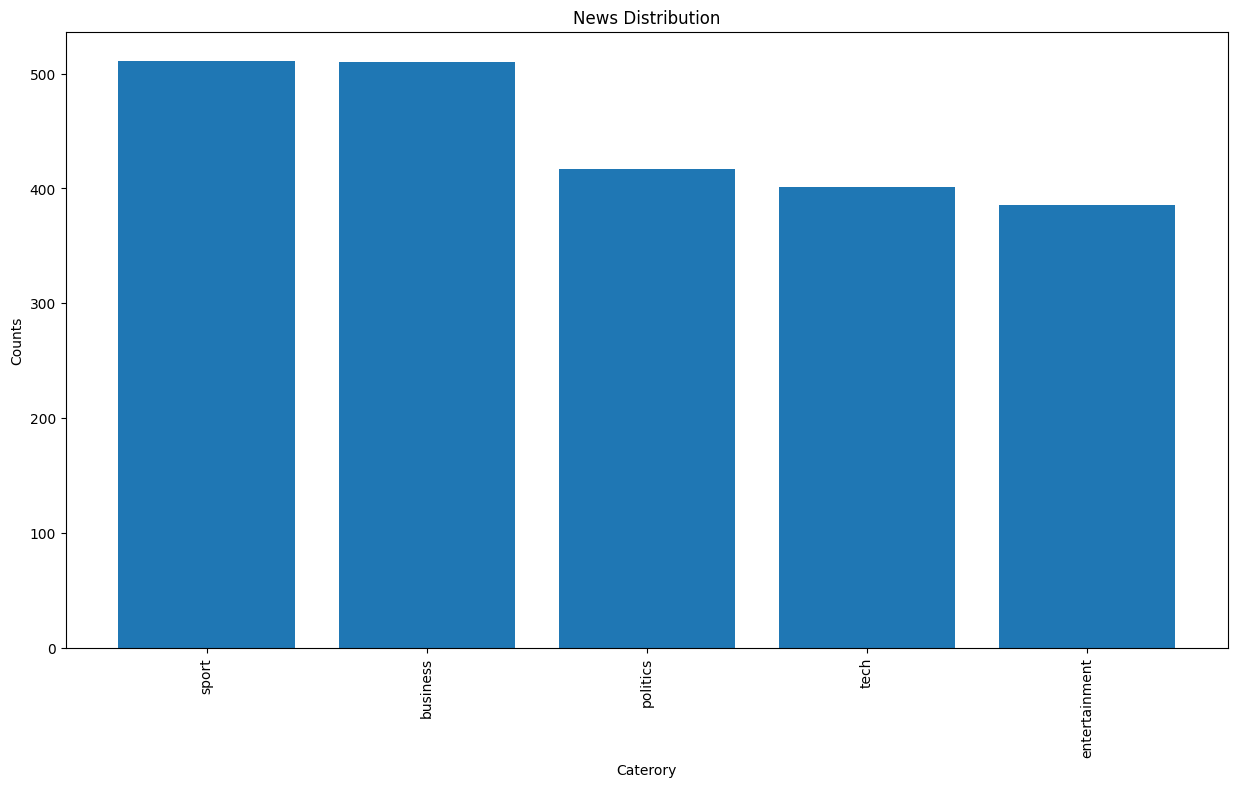

In [11]:
category = bbc_news['category'].value_counts()
category_name = category.index.to_list()
category_counts = category.values.tolist()
plt.figure(figsize=(15,8))
plt.bar(category_name,category_counts)
plt.xlabel('Caterory')
plt.xticks(rotation=90)
plt.ylabel('Counts')
plt.title("News Distribution")
plt.show()

## Text Cleaning
In this step we will convert text to lowercase and removing punctuations,numbers and stopwords.
Since we are performing text classification, removing stopwords help us focus on relevant words which provide semantic value to text analysis.

In [12]:
# def remove_punctuation_numbers(text):
#     tokens = word_tokenize(text)
#     clean_text = ' '.join([word for word in tokens if word.isalpha()])
#     return clean_text
#     #return text.translate(str.maketrans('', '', string.punctuation))

# bbc_news['text_without_punctuations']=bbc_news['text'].apply(remove_punctuation_numbers)

# len(bbc_news['text_without_punctuations'][0].split(' '))

# stop_words = set(stopwords.words('english'))
# def remove_stopwords(text):
#     tokens = word_tokenize(text)
#     clean_text = ' '.join([word for word in tokens if word not in stop_words])
#     return clean_text

# bbc_news['text_without_stopwords']=bbc_news['text_without_punctuations'].apply(remove_stopwords)

# len(bbc_news['text_without_stopwords'][0].split(' '))

In [13]:
# Removing punctuations,numbers and stopwords 
bbc_news['text']=bbc_news['text'].str.lower()
stop_words = set(stopwords.words('english'))
def clean_text(text):
    tokens = word_tokenize(text)
    clean_text = ' '.join([word for word in tokens if word.isalpha() and word not in stop_words])
    return clean_text

In [ ]:
bbc_news['processed_text']=bbc_news['text'].apply(clean_text)
bbc_news = bbc_news.drop('text',axis=1)

## Label Encoding
Converting news categories into numerical labels.
Categories are mapped as following:

* 'business': 0,
* 'entertainment': 1,
* 'politics': 2,
* 'sport': 3,
* 'tech': 4


In [ ]:
le = LabelEncoder()
bbc_news['encoded_category'] = le.fit_transform(bbc_news['category'])

bbc_news = bbc_news.drop('category',axis=1)

In [ ]:
# le_name_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
# print(le_name_mapping)

# Applying Machine Learning 

In [ ]:
#Splitting dataset into training(90%) and testing(10%)
X_train,X_test,y_train,y_test = train_test_split(bbc_news['processed_text'],bbc_news['encoded_category'],random_state=42,test_size=0.1)

## TF-IDF Vectorization
Converting our raw text data to numerical vectors.


* fit_transform() on X_train: Learns the vocabulary and calculates IDF (Inverse Document Frequency) scores exclusively from the training set.
* transform() on X_test: Converts test data into vectors based only on the training vocabulary. If you fit the vectorizer on the test set, your model gets indirect clues about test data, resulting in artificially high accuracy metrics that will fail in the real world.


In [ ]:
tf_idf_vec = TfidfVectorizer()

X_train_tfidf = tf_idf_vec.fit_transform(X_train)
X_test_tfidf = tf_idf_vec.transform(X_test)

## Training ML model - Logistic Regression

In [ ]:
logistic_reg = LogisticRegression()

In [20]:
logistic_reg.fit(X_train_tfidf,y_train)

LogisticRegression()

In [21]:
y_pred = logistic_reg.predict(X_test_tfidf)

## Model Evaluation
Evaluating accuracy score, confusion matrix,classification report

In [22]:
print("Accuracy_score" ,accuracy_score(y_test, y_pred))

Accuracy_score 0.9596412556053812


In [23]:
print("Classification Report \n",classification_report(y_test,y_pred))

Classification Report 
               precision    recall  f1-score   support

           0       0.93      0.91      0.92        46
           1       1.00      0.98      0.99        44
           2       0.94      0.96      0.95        47
           3       0.96      1.00      0.98        48
           4       0.97      0.95      0.96        38

    accuracy                           0.96       223
   macro avg       0.96      0.96      0.96       223
weighted avg       0.96      0.96      0.96       223



In [24]:
cm = confusion_matrix(y_test,y_pred)
print("Confusion Matrix \n",cm)

Confusion Matrix 
 [[42  0  3  1  0]
 [ 0 43  0  0  1]
 [ 2  0 45  0  0]
 [ 0  0  0 48  0]
 [ 1  0  0  1 36]]


In [25]:
logistic_reg.classes_

array([0, 1, 2, 3, 4])

<Figure size 800x800 with 0 Axes>

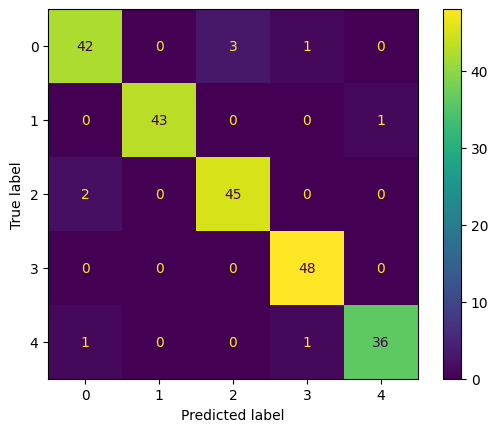

In [26]:
# Creating a visually appealing confusion matrix
#Category mappings ==> 'business': 0,'entertainment': 1,'politics': 2,'sport': 3,'tech': 4
plt.figure(figsize=(8, 8))
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=logistic_reg.classes_)
cm_display.plot()
plt.show()

# Deep Learning – Transformer Model

In [27]:
#Creating a copy of pre-processed dataset and renaming columns as transformers must required ‘label’ as a target column name.
bbc_news_trans_cp = bbc_news.copy()
bbc_news_trans_cp.columns = ['text','label']

#Converting the dataframe to HuggingFace Dataset
bbc_news_trans_ds = Dataset.from_pandas(bbc_news_trans_cp)

#Splitting dataset into training and testing
bbc_news_trans_ds_split = bbc_news_trans_ds.train_test_split(test_size=0.1,seed=42)

bbc_news_trans_ds_split

## Loading a pre-trained Transformer model

pre_trained_model = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(pre_trained_model)
model = AutoModelForSequenceClassification.from_pretrained(
    pre_trained_model,
    num_labels=5
)




Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Tokenizing data

In [28]:
def tokenize_data(sample_data):
    return tokenizer(sample_data["text"], padding=True, truncation=True , max_length=256)

tokenized_train_dataset = bbc_news_trans_ds_split['train'].map(tokenize_data, batched=True)
tokenized_test_dataset = bbc_news_trans_ds_split['test'].map(tokenize_data, batched=True)

tokenized_train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
tokenized_test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

Map:   0%|          | 0/2002 [00:00<?, ? examples/s]

Map:   0%|          | 0/223 [00:00<?, ? examples/s]

In [29]:
#len(tokenized_train_dataset)

## Training model

In [30]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, preds)}

In [31]:
training_args = TrainingArguments(
    output_dir="./news_distilbert_classification_model",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=20
)

In [32]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,#using test dataset as evaluation dataset
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

In [33]:
print("\nTraining Model …")
trainer.train()


Training Model …


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy
1,0.329692,0.294270,0.964126
2,0.087569,0.208121,0.982063
3,0.040583,0.192350,0.982063


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=189, training_loss=0.3939150485096785, metrics={'train_runtime': 95.9187, 'train_samples_per_second': 62.616, 'train_steps_per_second': 1.97, 'total_flos': 397820880737280.0, 'train_loss': 0.3939150485096785, 'epoch': 3.0})

In [34]:
trainer.state.best_model_checkpoint

'./news_distilbert_classification_model/checkpoint-126'

In [35]:
# Save final model + tokenizer
trainer.save_model("./news_distilbert_classification_model")
tokenizer.save_pretrained("./news_distilbert_classification_model")
print(f"\n  Model saved to → {"./news_distilbert_classification_model"}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


  Model saved to → ./news_distilbert_classification_model


## Transformer Predictions - Building inference pipeline

In [36]:
#Creating a pipeline for inferencing with our best_model_checkpoint, in this case checkpoint-189.
inference_pipeline = pipeline(task="text-classification",model = './news_distilbert_classification_model/checkpoint-189',batch_size=16,truncation=True)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [37]:
#Calling the pipeline to perform inferencing on our test dataset.
list_ds = list(bbc_news_trans_ds_split['test']['text']) #Converting it to list as input is expected in format of list['str']
predictions_on_test_ds = inference_pipeline(list_ds)

In [38]:
predictions_on_test_ds[0:5] # We are getting a dictionary of keys 'label' and 'score'.

[{'label': 'LABEL_1', 'score': 0.9927260875701904},
 {'label': 'LABEL_2', 'score': 0.9931520223617554},
 {'label': 'LABEL_4', 'score': 0.993899941444397},
 {'label': 'LABEL_1', 'score': 0.9940701127052307},
 {'label': 'LABEL_1', 'score': 0.994454562664032}]

In [39]:
#predictions_on_test_ds[0]['label'].split('_')[1]

In [40]:
#Function to get only the label number e.g LABEL_1 => 1, LABEL_2 => 2 ; as we are expecting only a list of integers for different categories
y_pred = []
def get_label(predictions_on_test_ds):
    for prediction in predictions_on_test_ds:
        label = prediction['label'].split("_")[1]
        y_pred.append(int(label))
    return y_pred
        
y_pred = get_label(predictions_on_test_ds)

In [41]:
#y_pred[0:10] 

## Model Evaluation

In [42]:
# We need the actual labels of test dataset so that we can calculate metrics such as accuracy score, confusion matrix 
y_true = list(bbc_news_trans_ds_split['test']['label'])

In [43]:
print("Accuracy_score using transformer :" ,accuracy_score(y_true, y_pred))

Accuracy_score using transformer : 0.9820627802690582


In [44]:
cm_transformer = confusion_matrix(y_true,y_pred)
print("Confusion Matrix \n",cm_transformer)

Confusion Matrix 
 [[46  1  1  0  0]
 [ 0 44  1  0  0]
 [ 1  0 38  0  0]
 [ 0  0  0 56  0]
 [ 0  0  0  0 35]]


<Figure size 800x800 with 0 Axes>

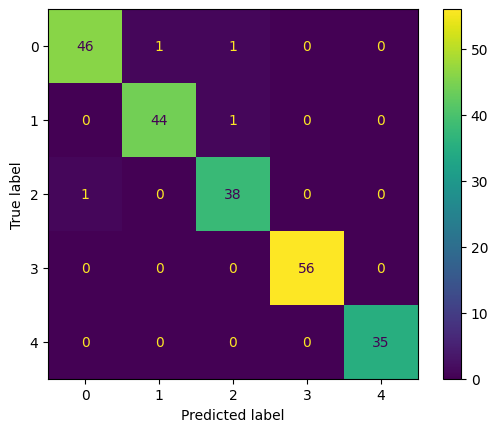

In [45]:
# Creating a visually appealing confusion matrix
#Category mappings ==> 'business': 0,'entertainment': 1,'politics': 2,'sport': 3,'tech': 4
plt.figure(figsize=(8, 8))
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm_transformer,
                              display_labels=logistic_reg.classes_)
cm_display.plot()
plt.show()

# Performance Comparison

## Comparing ML vs Transformer predictions

Let's take a look at **accuracy score**: <br>
Using Logistic regression model : **approx. 96%** <br>
Using distilbert-base-uncased transformer model : **approx. 98%**

Although in our case the difference might not seem that vast, but the transformer model works on understanding the context of text rather than just the keywords.<br>
Therefore is it able to establish relation between words and predict the labels more accurately.

# Generative AI – RAG (Retrieval-Augmented Generation)

## Document Creation
Convert cleaned news articles into document format where each article acts as a knowledge source.

In [46]:
''' The bbc_news dataframe has two columns 'processed_text' and 'encoded_category'. We are going to load the text data in
processed_text to a news_articles.txt document which will act as our knowledge base''' 

bbc_news['processed_text'].to_csv('news_articles.txt', index=False, header=False)

In [47]:
# Loading the news_articles.txt as document
loader = TextLoader("news_articles.txt")
documents = loader.load()

In [48]:
# Chunking: Split text into manageable pieces
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = text_splitter.split_documents(documents)

## Embedding Generation

In [56]:
# Embedding & Vector Store: Convert text to vectors and store them
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vectorstore = FAISS.from_documents(chunks, embeddings)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
